In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from dataset_creation import create_synthetic_supernovae_dataset, create_torch_supernovae_dataset
from config import DATA_VARIANCE_SCALE, DATAPOINT_SIZE

from Compression.Benchmarks.MOPED import moped

In [4]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

In [5]:
def estimator_given_theta(theta):
    z_obs, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    plt.scatter(z_obs,data[0, :])
    plt.show()
    # print(data.shape)
    # return 1e20*10**(-0.4*data[0, :])
    return data[0, :]

In [6]:
d_obs = create_synthetic_supernovae_dataset(1, [70.0**2])

# cov = cov * np.median(d_obs)

Creating sample: 1 of 1


In [7]:
fid_vals = np.array([70.0**2])

Creating sample: 1 of 1


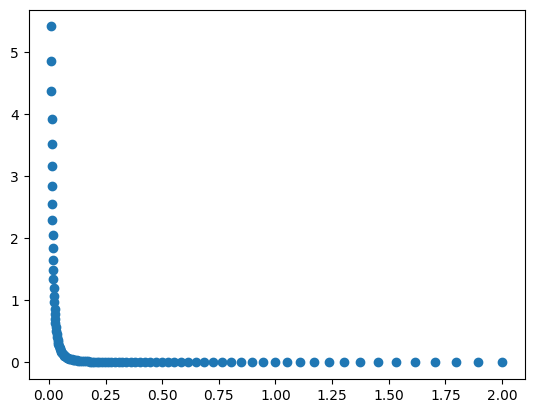

Creating sample: 1 of 1


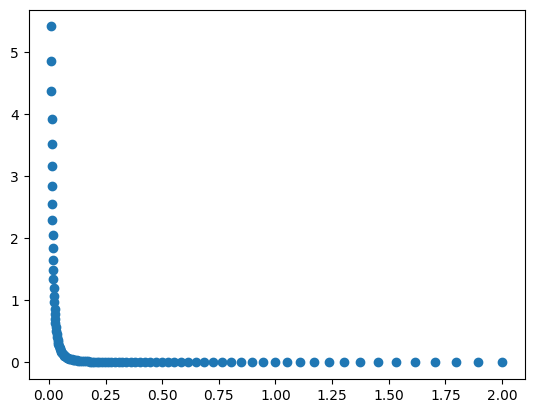

Creating sample: 1 of 1


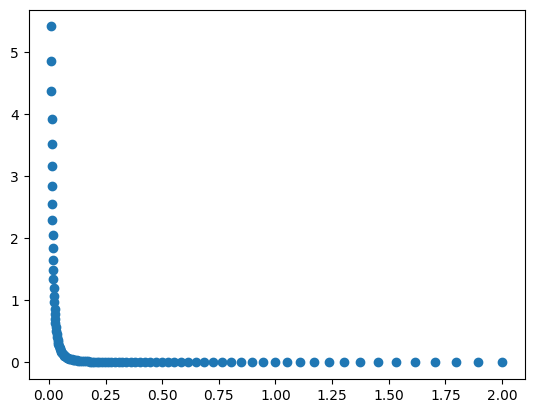

(1, 100)


In [8]:
b, F, d = moped(fid_vals, cov, estimator_given_theta)

In [9]:
b @ np.linalg.inv(cov) @b.T

array([[6.25e+18]])

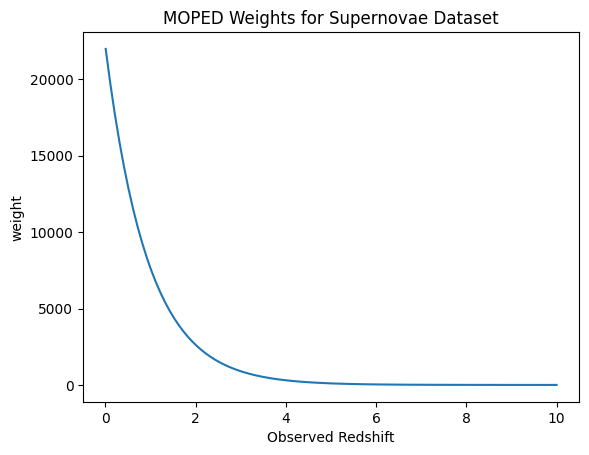

In [10]:
z_obs = np.linspace(0.01, 10.0, DATAPOINT_SIZE)
plt.plot(z_obs, b.T)
plt.xlabel('Observed Redshift')
plt.ylabel('weight')
plt.title('MOPED Weights for Supernovae Dataset')
plt.show()

In [11]:
F.item()

6.249999999999998e+18

Creating sample: 1 of 1
(1, 100) (100,)


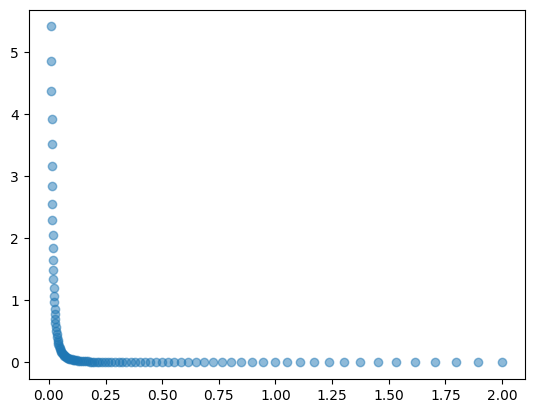

In [14]:
# z_obs = np.geomspace(0.01, 10.0, DATAPOINT_SIZE)
z_obs, d_obs, _, _ = create_synthetic_supernovae_dataset(1, [70.0**2])
print(d_obs.shape, z_obs.shape)
plt.scatter(z_obs, d_obs, alpha=0.5, label="Observed")  # Plot the observed distance modulus for each sample (optional)